In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import xarray as xr 
import matplotlib.pyplot as plt

In [3]:
import sys
import os
folders = [os.path.abspath("../modules/"), 
           os.path.abspath("../dataset/"),
           os.path.abspath("../benchmarking/")
        ]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)

from cost import DesignSpaceHierarchyCost, BinaryProbabilityCost, UtilityWithCost, SlicedCost, MarginalCost
from utility import MarginalEntropyAlongDimension, MarginalEntropyOverDimension 
from query_strategy import ArgMax 
from helpers import *
from pipelines import FeasibilityLabeler, ExperimentCost 

from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 
from AFL.double_agent.Pipeline import Pipeline 
from AFL.double_agent.Generator import CartesianGrid 
from AFL.double_agent.Preprocessor import Standardize 
from AFL.double_agent.AcquisitionFunction import MaxValueAF

In [4]:
expense = ExperimentCost(
        input_variable="design_space",
        input_dim="ds_dim",
        composition_dims_cost={"protein":10.0, "glycerol" :5.0},
        temperature_dim_cost={"temperature" : 20.0},
        output_variable="expense",
        name="ExperimentCost"
    ) 

In [5]:
sim = get_simulator("../dataset/")

In [6]:
ds_list = []
protein_init = np.random.uniform(low=0.0, high=80.0)
glycerol_init = np.random.uniform(low=0.0, high=12.0)
for temp in [0,10,20,30,40,50]:
    ds = sim.simple_expose({'protein':protein_init,'temperature':temp,'glycerol':glycerol_init})
    ds = ds.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds['step'] = 0
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_running = ds_init.copy() 

In [7]:
with Pipeline(name = "setup") as setup:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="ds_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 20},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 20},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 20}}
    )    
    Standardize(
        input_variable="design_space",
        output_variable="normalized_design_space",
        dim="sample",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="ds_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize-Grid",
    )

setup.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <Standardize>                       design_space ---> normalized_design_space
2  ) <Standardize-Grid>                  design_space_grid ---> normalized_design_space_grid

Input Variables
---------------
0) CartesianGridGenerator
1) design_space

Output Variables
----------------
0) normalized_design_space
1) normalized_design_space_grid


In [8]:
gp_params_mcmc = {"num_samples":20, "num_warmup":20, "method":"mcmc", "verbose":False} 

In [9]:
with Pipeline(name = "select_composition") as selcomp:
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phase",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-PhaseLabels",
    ) 
    DesignSpaceHierarchyCost(
        input_variable = "normalized_design_space_grid",
        grid_variable = "design_space_grid",
        grid_dim = "ds_grid",
        component_dim = "ds_dim",
        coordinates_order = ['temperature', 'protein', 'glycerol'], # from highest to lowest cost
        coordinates_offsets = [0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name = "DesignSpaceHierarchyCost",        
    )
    MarginalCost(
        input_variable = "hierarchy_cost",
        coordinate_dims = ['temperature'],
        component_dim = "ds_dim",
        grid_variable = "design_space_grid",
        output_variable="composition_hierarchy_cost",
        name= "MarginalCost",
    )
    MarginalEntropyOverDimension(
        input_variable= "phase_y_prob",
        coordinate_dims= ['temperature'],
        component_dim= "ds_dim",
        grid_variable= "design_space_grid",        
        output_variable="composition_utility",
        name= "UtilityMarginalEntropy",
    )    
    UtilityWithCost(
        input_variable = "composition_utility",
        cost_variables = ["composition_hierarchy_cost"],
        output_variable = "composition_utility_with_cost",
        name = "UtilityWithCost-Composition",
    )
    ArgMax(
        input_variable="composition_utility_with_cost",
        grid_variable="_".join(i for i in ['protein', 'glycerol'])+"_domain",
        output_prefix= "composition",
        name= "QueryStrategy-Composition",
    )

selcomp.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <DirichletGPExtrapolator-PhaseLabels> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phase_y_prob']
1  ) <DesignSpaceHierarchyCost>          normalized_design_space_grid ---> hierarchy_cost
2  ) <MarginalCost>                      hierarchy_cost ---> composition_hierarchy_cost
3  ) <UtilityMarginalEntropy>            phase_y_prob ---> composition_utility
4  ) <UtilityWithCost-Composition>       composition_utility ---> composition_utility_with_cost
5  ) <QueryStrategy-Composition>         composition_utility_with_cost ---> composition_next

Input Variables
---------------
0) normalized_design_space
1) phases
2) normalized_design_space_grid

Output Variables
----------------
0) composition_hierarchy_cost
1) composition_next


In [10]:
with Pipeline(name = "select_temperature") as seltemp:
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="phases",
        output_prefix="phasetemp",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-PhaseLabels-v2",
    )     
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_design_space",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="normalized_design_space_grid",
        grid_dim="ds_grid",
        sample_dim="sample",
        component_dim = "ds_dim",
        params=gp_params_mcmc,
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    BinaryProbabilityCost(
        input_variable="feasibility_y_prob",
        grid_variable = "design_space_grid",
        cost_label = 0,
        dim="ds_grid",
        output_variable = "feasibility_cost",
        name = "BinaryProbabilityCost"
    )
    MarginalEntropyAlongDimension(
        input_variable= "phasetemp_y_prob",
        conditioning_point= "composition_next",
        coordinate_dim= "temperature",
        grid_variable= "design_space_grid",        
        component_dim= "ds_dim",
        output_variable="temperature_utility",
        name= "MarginalEntropyAlongDimension",
    ) 
    SlicedCost(
        input_variable = "feasibility_cost",
        conditioning_point = "composition_next",
        coordinate_dim = "temperature",
        grid_variable = "design_space_grid",        
        component_dim = "ds_dim",
        output_variable = "temperature_cost",
        name = "SlicedCost",
    )   
    UtilityWithCost(
        input_variable = "temperature_utility",
        cost_variables = ["temperature_cost"],
        output_variable = "temperature_utility_with_cost",
        name = "AcquisitonWithCost-Temperature",
    )
    MaxValueAF(
        input_variables=['temperature_utility_with_cost'],
        grid_variable="temperature_domain",
        grid_dim="temperature_n",
        combine_coeffs=None,
        output_prefix="temperature",
        output_variable="temperature_next",
        decision_rtol=0.05,
        excluded_comps_variables="temperature_next",
        excluded_comps_dim=None,
        exclusion_radius=5.0,
        count=1,
        name="MaxValueAF",
    )  
seltemp.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <DirichletGPExtrapolator-PhaseLabels-v2> ['normalized_design_space', 'phases', 'normalized_design_space_grid'] ---> ['phasetemp_y_prob']
1  ) <FeasibilityLabeler>                phases ---> feasibility_labels
2  ) <DirichletGPExtrapolator-FeasibilityLabels> ['normalized_design_space', 'feasibility_labels', 'normalized_design_space_grid'] ---> ['feasibility_y_prob']
3  ) <BinaryProbabilityCost>             feasibility_y_prob ---> feasibility_cost
4  ) <MarginalEntropyAlongDimension>     phasetemp_y_prob ---> temperature_utility
5  ) <SlicedCost>                        feasibility_cost ---> temperature_cost
6  ) <AcquisitonWithCost-Temperature>    temperature_utility ---> temperature_utility_with_cost
7  ) <MaxValueAF>                        ['temperature_utility_with_cost', 'temperature_domain'] ---> temperature_next

Input Variab

In [11]:
def get_running_dataset(step, ds_old, ds_new):
    ds = ds_new.rename({'composition': 'design_space', 'component':'ds_dim'})
    ds['phases'] = int(ds.attrs['labels'])
    ds['step'] = step+1
    ds = xr.concat([ds], dim='sample')

    # Only append variables that have 'sample' in their dims
    sample_vars = [var for var in ds.data_vars if 'sample' in ds[var].dims]
    non_sample_vars = [var for var in ds_old.data_vars if 'sample' not in ds_old[var].dims]

    # Get the sample and non-sample data separately
    ds_running_samples = ds_old[sample_vars]
    ds_new_samples = ds[sample_vars]
    ds_running_non_samples = ds_old[non_sample_vars]

    # Manually concatenate sample-wise data
    ds_running_samples = xr.concat([ds_running_samples, ds_new_samples], dim='sample')

    # Rebuild ds_running with updated sample vars + preserved non-sample vars
    ds_running = xr.merge([ds_running_samples, ds_running_non_samples])

    return ds_running

KeyError: "No variable named 'temperature_next'. Variables on the dataset include ['q', 'ds_dim', 'protein_glycerol_d', 'I', 'I_noiseless', ..., 'feasibility_cost', 'temperature_utility', 'temperature_domain', 'temperature_cost', 'temperature_utility_with_cost']"

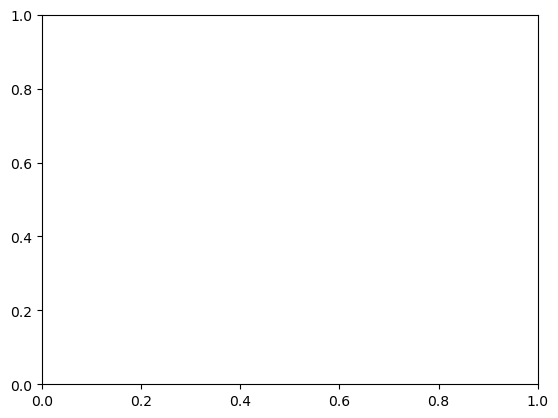

In [12]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

ds_running = ds_init.copy() 
temp_batch_size = 5
num_samples = 5

cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, temp_batch_size))
norm = Normalize(vmin=0, vmax=temp_batch_size-1)
for step in range(num_samples):
    ds_result = setup.calculate(ds_running, disable_progress_bar=True)
    ds_result = selcomp.calculate(ds_result, disable_progress_bar=True)
    # ds_running['composition_next'] = ds_result['composition_next']
    # ds_running['phase_entropy'] = ds_result['phase_entropy']
    # ds_running['phase_y_prob'] = ds_result['phase_y_prob']
    ds_running = ds_result.copy()

    # Measure sample at the same composition from `sel_comp` but at different temperatures.
    # We update the feasibility model each time, and sample a temperature that helps us
    # decode the feasibility boundary better.
    fig, ax = plt.subplots()

    for i in range(temp_batch_size):
        ds_result = setup.calculate(ds_running, disable_progress_bar=True)
        ds_result = seltemp.calculate(ds_result, disable_progress_bar=True)
        sample = {"protein": ds_result.composition_next.sel({"protein_glycerol_d":"protein"}).values.item(),
                  "glycerol" : ds_result.composition_next.sel({"protein_glycerol_d":"glycerol"}).values.item(),
                  "temperature" : ds_result.temperature_next.values.item()
            } 
        ds_new = sim.simple_expose(sample)
        ds_running = get_running_dataset(step, ds_running, ds_new)
        color = colors[i]
        ax.plot(ds_result.temperature_domain.values,
                ds_result.temperature_utility_with_cost.values,
                color = color
            )
        opt_temp = ds_result.temperature_next.values.item() 
        ax.axvline(opt_temp, ls='--', color=color)

    ax.set_xlabel("Temperature")
    ax.set_ylabel("u(D)")
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Temperature Axis Batch Number', rotation=270, labelpad=15)
    plt.show()

    out = expense.calculate(ds_result)
    
    fig, axs = plot_progress(ds_result, 
                "design_space", 
                "design_space_grid", 
                "ds_dim", 
                ['protein', 'glycerol'],
                "temperature",
                "phases",
                "phase_entropy",
                "feasibility_y_prob"
            )
    fig.suptitle(f"Samples {step+1}/{num_samples} Measurements {len(ds_running.sample)} " + 
                f"and cost {out.output['expense'].values.item():.3f}")
    plt.show()

In [ ]:
ds_running

<xarray.Dataset> Size: 1MB
Dimensions:                        (sample: 31, q: 281, ds_dim: 3,
                                    ds_grid: 8000, phase_n_classes: 3,
                                    protein_glycerol_n: 400,
                                    protein_glycerol_d: 2, composition_next_n: 1)
Coordinates:
  * q                              (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                         (ds_dim) object 24B 'protein' ... 'glycerol'
  * protein_glycerol_d             (protein_glycerol_d) <U8 64B 'protein' 'gl...
Dimensions without coordinates: sample, ds_grid, phase_n_classes,
                                protein_glycerol_n, composition_next_n
Data variables: (12/18)
    I                              (sample, q) float64 70kB 1.95 1.937 ... 1.027
    I_noiseless                    (sample, q) float64 70kB 1.95 1.937 ... 1.027
    dI                             (sample, q) float64 70kB 0.0 0.0 ... 0.0 0.0
    design_space                   (sample, ds_dim) float64 744B 68.39 ... 10.74
    phases                         (sample) int64 248B 2 1 1 1 0 0 ... 1 1 1 0 1
    step                           (sample) int64 248B 0 0 0 0 0 0 ... 5 5 5 5 5
    ...                             ...
    hierarchy_cost                 (ds_grid) float64 64kB 0.181 ... 0.2504
    composition_hierarchy_cost     (protein_glycerol_n) float64 3kB 0.1838 .....
    protein_glycerol_domain        (protein_glycerol_n, protein_glycerol_d) float64 6kB ...
    composition_utility            (protein_glycerol_n) float64 3kB 0.7864 .....
    composition_utility_with_cost  (protein_glycerol_n) float64 3kB 0.6419 .....
    composition_next               (composition_next_n, protein_glycerol_d) float64 16B ...
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [ ]:
ds_result

<xarray.Dataset> Size: 2MB
Dimensions:                        (q: 281, ds_dim: 3, protein_glycerol_d: 2,
                                    sample: 30, ds_grid: 8000,
                                    phase_n_classes: 3,
                                    protein_glycerol_n: 400,
                                    composition_next_n: 1,
                                    phasetemp_n_classes: 3,
                                    feasibility_n_classes: 2,
                                    temperature_n: 20, AF_sample: 1)
Coordinates:
  * q                              (q) float64 2kB 0.003836 0.004348 ... 0.6334
  * ds_dim                         (ds_dim) object 24B 'protein' ... 'glycerol'
  * protein_glycerol_d             (protein_glycerol_d) <U8 64B 'protein' 'gl...
Dimensions without coordinates: sample, ds_grid, phase_n_classes,
                                protein_glycerol_n, composition_next_n,
                                phasetemp_n_classes, feasibility_n_classes,
                                temperature_n, AF_sample
Data variables: (12/35)
    I                              (sample, q) float64 67kB 1.95 1.937 ... 1.0
    I_noiseless                    (sample, q) float64 67kB 1.95 1.937 ... 1.0
    dI                             (sample, q) float64 67kB 0.0 0.0 ... 0.0 0.0
    design_space                   (sample, ds_dim) float64 720B 68.39 ... 10.74
    phases                         (sample) int64 240B 2 1 1 1 0 0 ... 1 1 1 1 0
    step                           (sample) int64 240B 0 0 0 0 0 0 ... 4 5 5 5 5
    ...                             ...
    temperature_utility            (temperature_n) float64 160B 0.5349 ... 0....
    temperature_domain             (temperature_n) float64 160B 0.0 ... 50.0
    temperature_cost               (temperature_n) float64 160B 0.03697 ... 0...
    temperature_utility_with_cost  (temperature_n) float64 160B 0.5151 ... 0....
    temperature_decision_surface   (temperature_n) float64 160B 0.8091 ... 0.0
    temperature_next               (AF_sample) float64 8B 34.21
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label